In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

import jax
import jax.numpy as jnp

import wavefunctions, trajectory

### Plot hyperparameter sampling trials

10.574815061243621 -0.0197727189
1.5197744156676858 -0.0197667596
6.461421779405864 -0.0197725902
12.234852135654865 -0.0197731688
76.145931670902 -0.0197745403
41.66696590217523 -0.0197732542
39.44564908680039 -0.0197732889
35.71027420680315 -0.019774959
0.18365412139632042 -0.0197405419
21.34733960256371 -0.0197736846
17.671222485499328 -0.0197741585
0.12418910552231724 -0.0197399002
1.4579983642903123 -0.0197668562
0.5530435800593733 -0.0197516234
0.19679871254109252 -0.0197399801
29.033937482517178 -0.019774205


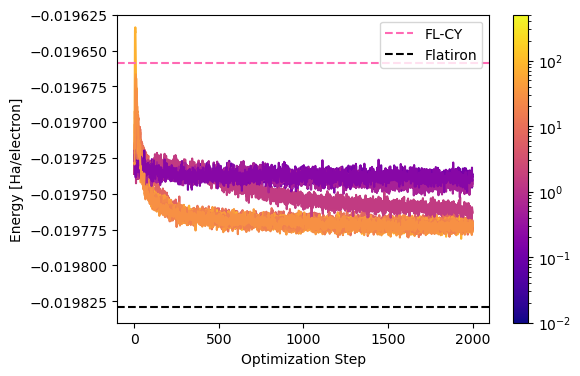

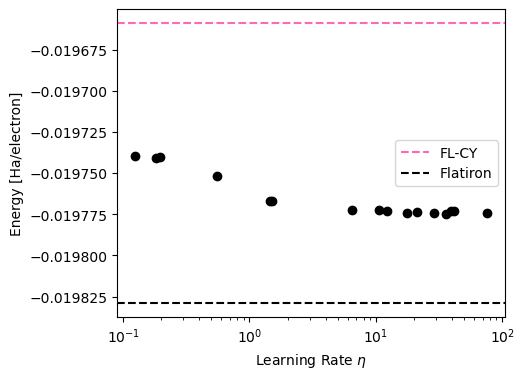

In [5]:
path = "gaussian-reference/MP-init-gaussian/rs{}_trial{}/{}"
path = "salamander/NSJB-FL/rs{}_trial{}/{}"
path = "gaussian-reference/MP-init-gaussian/rs{}_trial{}/{}"

r_ws = "50"

cmap = plt.cm.plasma
norm = mpl.colors.LogNorm(1e-2, 5e2)

final_vals = []

plt.figure(figsize=(6,4))

# "r_ws" : ( FL_ref , WC_ref, flatiron )
hard_vals = {
    "10" : ( -0.084474 , np.nan , np.nan ),
    "20" : ( -0.045929 , -0.045975 , -0.04637 ),
    "30" : ( -0.031689 , -0.031807 , -0.03197 ),
    "40" : ( -0.0242460 , -0.0243690 , -0.024451 ),
    "50" : ( -0.0196589 , -0.0197745 , -0.019829 )
}

for trial in range(16):

    energy_traj = np.loadtxt(path.format(
        r_ws, str(trial), "energy_traj.txt"
    ))
    eta = np.loadtxt(path.format(
        r_ws, str(trial), "hyperparameters.txt"
    ))

    (mean,_) = trajectory.getStatistics(path.format(
        r_ws, str(trial), "statistics.txt"
    ))
    final_vals.append([eta, mean])

    print(eta, mean)

    if mean is None:
        continue;
    
    color = cmap(norm(eta))
    plt.plot(energy_traj, color=color)

plt.axhline(y=hard_vals[r_ws][0], color='hotpink', linestyle='--', label='FL-CY')
plt.axhline(y=hard_vals[r_ws][2], color='black', linestyle='--', label='Flatiron')

min_val = np.nanmin([hard_vals[r_ws][0],hard_vals[r_ws][2]])
max_val = np.nanmax([hard_vals[r_ws][0],hard_vals[r_ws][2]])
#plt.ylim([1.1*min_val,0.9*max_val])

sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])  # older matplotlib compatibility
cbar = plt.colorbar(sm, ax=plt.gca())

if r_ws == "10":
    plt.ylim([-0.09, -0.08])
elif r_ws == "20":
    plt.ylim([-0.047, -0.045])
elif r_ws == "30":
    plt.ylim([-0.0325, -0.0315])
elif r_ws == "50":
    plt.ylim([-0.01984, -0.019625])
else:
    raise Exception()

plt.xlabel("Optimization Step")
plt.ylabel("Energy [Ha/electron]")
plt.legend()
plt.show()

final_vals = np.array(final_vals)

plt.figure(figsize=(5,4))
plt.scatter(final_vals[:,0], final_vals[:,1], color='black')
plt.axhline(y=hard_vals[r_ws][0], color='hotpink', linestyle='--', label='FL-CY')
plt.axhline(y=hard_vals[r_ws][2], color='black', linestyle='--', label='Flatiron')
plt.xscale('log')
plt.xlabel(r"Learning Rate $\eta$")
plt.ylabel("Energy [Ha/electron]")
plt.legend()
plt.show()

### Compare best runs

CYJastrow	-0.0459288735
MP	-0.0459896451
gaussian	-0.045971532


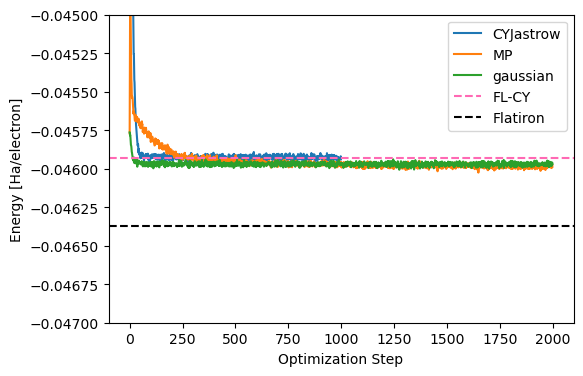

In [4]:
path = "{}/rs{}_best/{}"

r_ws = "20"
compare_vals = [
    ( "gaussian-reference/CYJastrow" , "CYJastrow" ),
    ( "gaussian-reference/MP-init-gaussian" , "MP" ),
    ( "gaussian-reference/gaussian" , "gaussian" ),
]

plt.figure(figsize=(6,4))

# "r_ws" : ( FL_ref , WC_ref, flatiron )
hard_vals = {
    "10" : ( -0.084474 , np.nan , np.nan ),
    "20" : ( -0.045929 , -0.045975 , -0.04637 ),
    "30" : ( -0.031689 , -0.031807 , -0.03197 ),
    "40" : ( -0.0242460 , -0.0243690 , -0.024451 ),
    "50" : ( -0.0196589 , -0.0197745 , -0.019829 )
}

for (filename, label) in compare_vals:

    energy_traj = np.loadtxt(path.format(
        filename, r_ws, "energy_traj.txt"
    ))

    (mean,_) = trajectory.getStatistics(path.format(
        filename, r_ws, "statistics.txt"
    ))

    print("{}\t{}".format(label, mean))

    if mean is None:
        continue;
    
    plt.plot(energy_traj, label=label)

plt.axhline(y=hard_vals[r_ws][0], color='hotpink', linestyle='--', label='FL-CY')
plt.axhline(y=hard_vals[r_ws][2], color='black', linestyle='--', label='Flatiron')

if r_ws == "10":
    plt.ylim([-0.09, -0.08])
elif r_ws == "20":
    plt.ylim([-0.047, -0.045])
elif r_ws == "30":
    plt.ylim([-0.0325, -0.0315])
else:
    raise Exception()

plt.xlabel("Optimization Step")
plt.ylabel("Energy [Ha/electron]")
plt.legend()
plt.show()